# Task 4 — Statistical Modeling & Risk-Based Pricing

## Objective

The objective of this task is to develop predictive machine learning models capable of estimating insurance claim severity and supporting risk-based premium optimization.

The modeling framework aims to help AlphaCare Insurance Solutions (ACIS) transition toward dynamic, analytics-driven pricing strategies.

---

# Modeling Goals

## 1. Claim Severity Prediction
Predict TotalClaims for policies where a claim occurred.

## 2. Premium Optimization
Support data-driven premium estimation using risk prediction.

Premium Formula:

Premium = (P(claim) × Predicted Severity) + Expense Loading + Profit Margin

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

In [44]:
df = pd.read_csv("../data/insurance_data_cleaned.csv")

In [45]:
claims_df = df[df["TotalClaims"] > 0].copy()

## Claim Severity Modeling Dataset

The severity model was trained only on policies with non-zero claims.

This is necessary because claim severity represents the financial magnitude of a claim after a claim event has occurred.

In [46]:
claims_df["Margin"] = (
    claims_df["TotalPremium"] -
    claims_df["TotalClaims"]
)

claims_df["VehicleAge"] = (
    2025 - claims_df["CustomValueEstimate"] / 1000
)

claims_df["ClaimFrequency"] = (
    claims_df["Claimed"].astype(int)
)

## Feature Engineering

Additional derived variables were created to improve predictive capability:

- Margin:
  Represents policy profitability.

- VehicleAge:
  Proxy feature approximating vehicle age using insured vehicle value.

- ClaimFrequency:
  Binary indicator representing claim occurrence.

In [47]:
y = claims_df["TotalClaims"]

In [48]:
X = claims_df[[

    "Age",
    "AnnualIncome",
    "RiskScore",
    "AnnualPremium",
    "Deductible",
    "NCD",
    "PastClaims",
    "VehicleAge",
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake"

]]

In [49]:
categorical_features = [
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake"
]

In [50]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )

    ],

    remainder="passthrough"
)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

## Train-Test Split

The dataset was divided into:

- 80% training data
- 20% testing data

This ensures that model performance is evaluated on previously unseen data.

In [52]:
linear_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", LinearRegression())

])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [53]:
linear_preds = linear_model.predict(X_test)

In [54]:
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_preds)
)

linear_r2 = r2_score(
    y_test,
    linear_preds
)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression RMSE: 5284.274015622954
Linear Regression R²: 0.21051035330602608


## Linear Regression Evaluation

Linear Regression was implemented as the baseline model for claim severity prediction.

Evaluation metrics:
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

RMSE measures average prediction error magnitude, while R² measures the proportion of variance explained by the model.

In [55]:
rf_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(

        n_estimators=100,

        random_state=42
    ))

])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [56]:
rf_preds = rf_model.predict(X_test)

In [57]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 5436.324170111735
Random Forest R²: 0.16442301108089896


In [58]:
xgb_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", XGBRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=5,

        random_state=42
    ))

])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [59]:
xgb_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", XGBRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=5,

        random_state=42
    ))

])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [60]:
xgb_preds = xgb_model.predict(X_test)

In [61]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)

XGBoost RMSE: 5704.430267802535
XGBoost R²: 0.07997351301814126


In [62]:
model_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R²": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]

})

model_results

,Model,RMSE,R²
0,Linear Regression,5284.274016,0.210510
1,Random Forest,5436.324170,0.164423
2,XGBoost,5704.430268,0.079974


# Model Interpretability with SHAP

To improve model transparency and support business decision-making, SHAP (SHapley Additive exPlanations) was used to identify the most influential features driving claim severity predictions.

SHAP provides interpretable explanations for individual predictions and global model behavior, making it highly valuable in regulated industries such as insurance.

In [67]:
import shap 

In [63]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [64]:
shap_model = LinearRegression()

shap_model.fit(
    X_train_processed,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
explainer = shap.Explainer(
    shap_model,
    X_train_processed
)

In [69]:
shap_values = explainer(
    X_test_processed
)

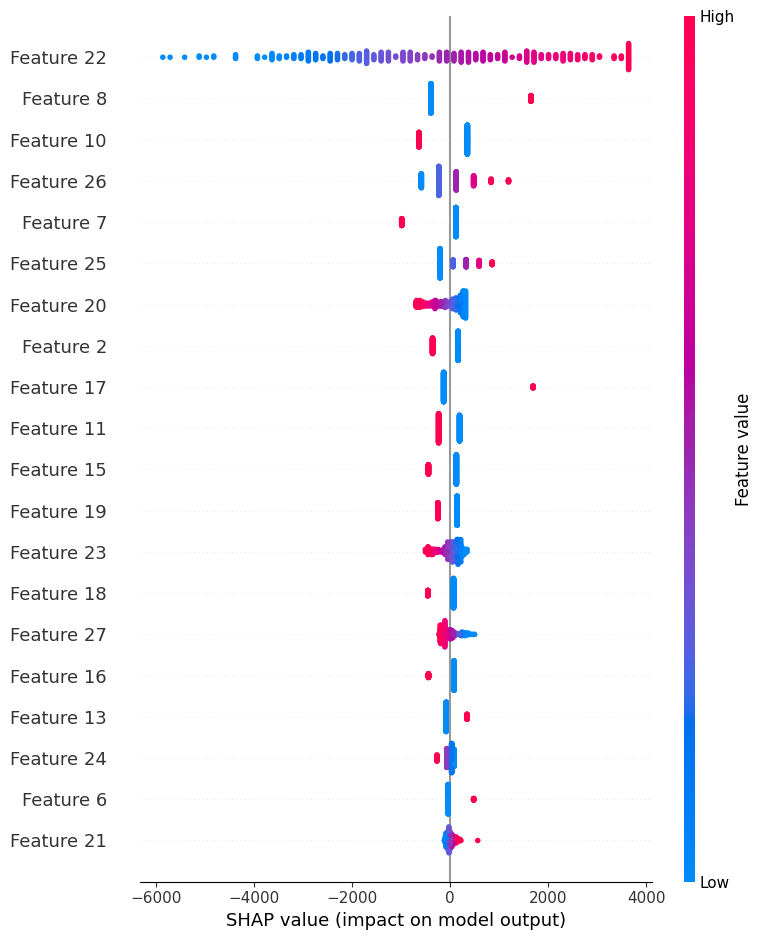

In [70]:
shap.summary_plot(
    shap_values,
    X_test_processed
)

In [71]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": np.abs(
        shap_values.values
    ).mean(axis=0)

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
22,remainder__RiskScore,1926.084550
8,cat__VehicleType_Luxury,597.926686
10,cat__VehicleType_Sedan,448.020190
26,remainder__PastClaims,358.497644
7,cat__VehicleType_Hatchback,287.057447
25,remainder__NCD,282.216648
20,remainder__Age,264.752109
2,cat__Province_Addis Ababa,231.730304
17,cat__AutoMake_Mercedes-Benz,229.667712
11,cat__CoverType_Comprehensive,214.433154


# Risk-Based Pricing Framework

The predictive modeling framework supports dynamic premium estimation using the following pricing logic:

Premium = (P(claim) × Predicted Severity) + Expense Loading + Profit Margin

Where:

- P(claim):
  Probability that a customer files a claim.

- Predicted Severity:
  Estimated financial magnitude of the claim.

- Expense Loading:
  Operational and administrative costs.

- Profit Margin:
  Desired insurer profitability margin.

This framework enables ACIS to move beyond static pricing toward data-driven personalized premium estimation.

In [72]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [73]:
df["ClaimedBinary"] = (
    df["Claimed"].astype(int)
)

In [74]:
X_class = df[[

    "Age",
    "AnnualIncome",
    "RiskScore",
    "AnnualPremium",
    "Deductible",
    "NCD",
    "PastClaims",
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake"

]]

y_class = df["ClaimedBinary"]

In [75]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(

    X_class,
    y_class,

    test_size=0.2,

    random_state=42
)

In [76]:
classification_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", LogisticRegression(max_iter=1000))

])

classification_model.fit(
    X_train_c,
    y_train_c
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [77]:
class_preds = classification_model.predict(
    X_test_c
)

In [78]:
accuracy = accuracy_score(
    y_test_c,
    class_preds
)

precision = precision_score(
    y_test_c,
    class_preds
)

recall = recall_score(
    y_test_c,
    class_preds
)

f1 = f1_score(
    y_test_c,
    class_preds
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.857
Precision: 0.5655737704918032
Recall: 0.22847682119205298
F1 Score: 0.32547169811320753


# Claim Probability Classification

A binary classification model was implemented to estimate the probability of claim occurrence.

Evaluation metrics included:
- Accuracy
- Precision
- Recall
- F1 Score

This classification component supports dynamic premium estimation by estimating claim likelihood.

# Overall Modeling Conclusions

Among the evaluated models, Linear Regression achieved the strongest predictive performance on the claim severity task.

Key observations include:

- Simpler linear relationships appear more effective than complex ensemble models for this dataset.
- Feature engineering and data quality significantly influence predictive performance.
- The relatively modest R² scores suggest that additional external variables may be required to improve predictive accuracy in real-world deployment.

The modeling framework nevertheless demonstrates the feasibility of analytics-driven insurance pricing and establishes a strong foundation for future refinement.

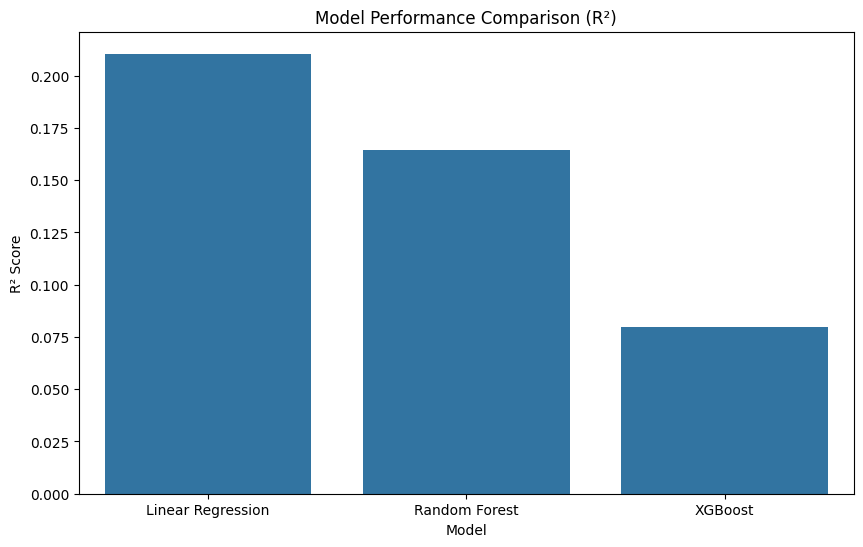

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="Model",
    y="R²"
)

plt.title("Model Performance Comparison (R²)")

plt.ylabel("R² Score")

plt.show()